# Early Student Dropout Prediction

This notebook runs the final experiment for the paper:
**Early Student Dropout Prediction Using Pre-Acceptance Variables: A Comparison of Gaussian Naive Bayes and XGBoost**.

This version is configured for local execution with the dataset stored at:
- `Data/Raw/dataset.csv`

The notebook automatically creates:
- `Data/Processed/` for cached processed data
- `results/` for CSV/TXT outputs
- `figures/` for paper-ready figures

Final paper visuals generated here:
- `figures/fig2_feature_boundary.png`
- `figures/fig3_xgboost_setting_b_feature_importance.png`


## 1. Set Local Dataset Path

This notebook is configured to run locally. Put the raw Kaggle dataset at:

`Data/Raw/dataset.csv`

Processed data will be cached in `Data/Processed/` so repeated runs do not need to repeat preprocessing.


In [19]:
from pathlib import Path

# Local dataset path.
DATA_PATH = Path("Data/Raw/dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset file not found: {DATA_PATH.resolve()}\n"
        "Please place the Kaggle CSV file at Data/Raw/dataset.csv."
    )

print(f"Using dataset file: {DATA_PATH.resolve()}")


Using dataset file: C:\RM_GitHub_Ready\Data\Raw\dataset.csv


## 2. Import Libraries and Create Output Folders

In [20]:
import sys
import subprocess
import importlib.util
from pathlib import Path
import warnings
import joblib

required_packages = {
    'xgboost': 'xgboost',
    'imblearn': 'imbalanced-learn'
}

for import_name, pip_name in required_packages.items():
    if importlib.util.find_spec(import_name) is None:
        print(f'Installing {pip_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20

RAW_DATA_DIR = Path('Data/Raw')
PROCESSED_DATA_DIR = Path('Data/Processed')
RESULTS_DIR = Path('results')
FIGURES_DIR = Path('figures')

for folder in [RAW_DATA_DIR, PROCESSED_DATA_DIR, RESULTS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print('Project folders are ready:')
print(f'- {RAW_DATA_DIR}/')
print(f'- {PROCESSED_DATA_DIR}/')
print(f'- {RESULTS_DIR}/')
print(f'- {FIGURES_DIR}/')


Project folders are ready:
- Data\Raw/
- Data\Processed/
- results/
- figures/


## 3. Load Dataset and Clean Column Names

In [21]:
def clean_column_name(col):
    # Handles UTF-8 BOM issue such as '﻿Marital status'
    return str(col).replace('﻿', '').strip()

# sep=None allows pandas to infer comma/semicolon separators.
df_raw = pd.read_csv(DATA_PATH, sep=None, engine='python')
df_raw = df_raw.rename(columns={col: clean_column_name(col) for col in df_raw.columns})

if 'Target' not in df_raw.columns:
    raise KeyError("Column 'Target' was not found. Please check the uploaded CSV file.")

df_raw['Target'] = df_raw['Target'].astype(str).str.replace('﻿', '', regex=False).str.strip()

print('Dataset shape:', df_raw.shape)
display(df_raw.head())
print('Target values:', sorted(df_raw['Target'].unique()))

Dataset shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Target values: ['Dropout', 'Enrolled', 'Graduate']


## 4. Define Pre-Acceptance Feature Settings

Setting A contains background-only variables.  
Setting B contains Setting A plus application-related variables.  
Post-acceptance and semester-based variables are excluded by design.

In [22]:
setting_a_features = [
    'Marital status',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Gender',
    'Age at enrollment',
    'International',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

application_related_features = [
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification'
]

setting_b_features = setting_a_features + application_related_features

excluded_features = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)'
]

all_needed_columns = setting_b_features + ['Target']
missing_columns = [col for col in all_needed_columns if col not in df_raw.columns]
if missing_columns:
    raise KeyError(f'Missing columns in dataset: {missing_columns}')

feature_setting_table = pd.DataFrame({
    'Feature Group': ['Setting A', 'Setting B additional', 'Excluded by design'],
    'Description': [
        'Background-only variables',
        'Application-related variables added to Setting A',
        'Post-acceptance and semester-based variables'
    ],
    'Variables': [
        ', '.join(setting_a_features),
        ', '.join(application_related_features),
        ', '.join(excluded_features)
    ]
})

display(feature_setting_table)
feature_setting_table.to_csv(RESULTS_DIR / 'feature_setting_definition.csv', index=False)
print('Saved:', RESULTS_DIR / 'feature_setting_definition.csv')

,Feature Group,Description,Variables
0,Setting A,Background-only variables,"Marital status, Nacionality, Mother's qualific..."
1,Setting B additional,Application-related variables added to Setting A,"Application mode, Application order, Course, D..."
2,Excluded by design,Post-acceptance and semester-based variables,"Debtor, Tuition fees up to date, Scholarship h..."


Saved: results\feature_setting_definition.csv


## 5. Generate Fig. 2 — Pre-Acceptance Feature Boundary

This figure is intended for Chapter IV because it explains the main feature boundary of the paper instead of repeating the metrics table.

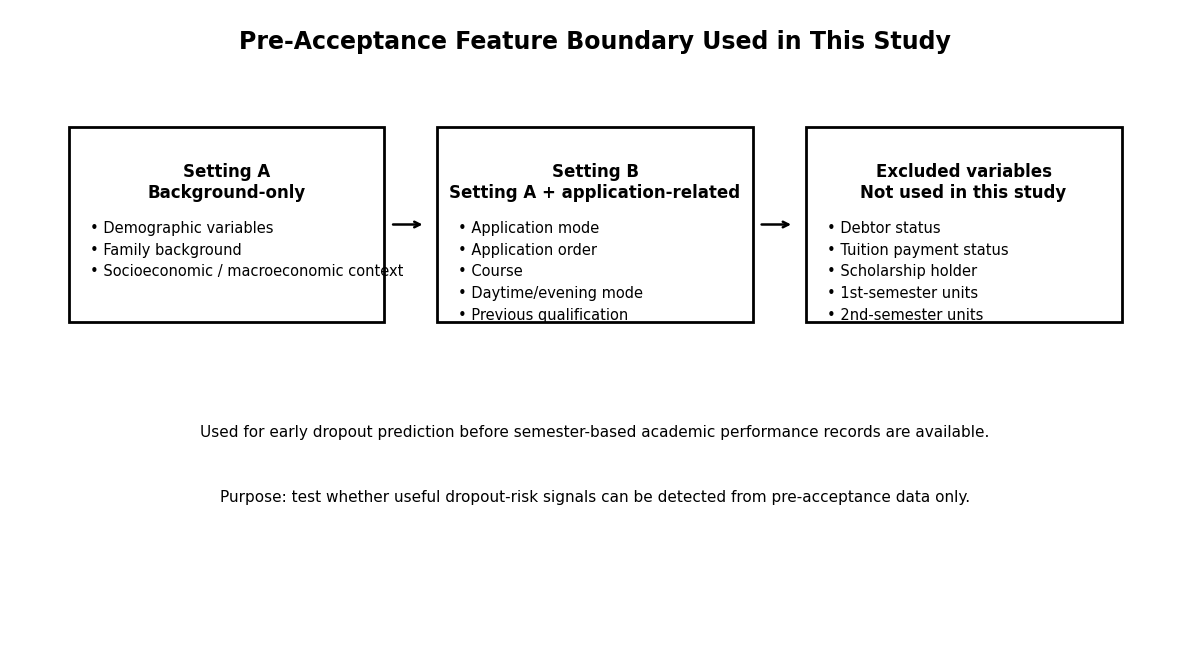

Saved: figures\fig2_feature_boundary.png


In [23]:
def generate_feature_boundary_figure(output_path):
    fig, ax = plt.subplots(figsize=(12, 6.8))
    ax.axis('off')

    title = 'Pre-Acceptance Feature Boundary Used in This Study'
    ax.text(0.5, 0.95, title, ha='center', va='center', fontsize=17, fontweight='bold')

    boxes = [
        {
            'x': 0.05,
            'y': 0.52,
            'w': 0.27,
            'h': 0.30,
            'header': 'Setting A\nBackground-only',
            'body': '• Demographic variables\n• Family background\n• Socioeconomic / macroeconomic context'
        },
        {
            'x': 0.365,
            'y': 0.52,
            'w': 0.27,
            'h': 0.30,
            'header': 'Setting B\nSetting A + application-related',
            'body': '• Application mode\n• Application order\n• Course\n• Daytime/evening mode\n• Previous qualification'
        },
        {
            'x': 0.68,
            'y': 0.52,
            'w': 0.27,
            'h': 0.30,
            'header': 'Excluded variables\nNot used in this study',
            'body': '• Debtor status\n• Tuition payment status\n• Scholarship holder\n• 1st-semester units\n• 2nd-semester units'
        }
    ]

    for b in boxes:
        rect = plt.Rectangle((b['x'], b['y']), b['w'], b['h'], fill=False, linewidth=2)
        ax.add_patch(rect)
        ax.text(b['x'] + b['w']/2, b['y'] + b['h'] - 0.055, b['header'],
                ha='center', va='top', fontsize=12, fontweight='bold')
        ax.text(b['x'] + 0.018, b['y'] + b['h'] - 0.145, b['body'],
                ha='left', va='top', fontsize=10.5, linespacing=1.55)

    ax.annotate('', xy=(0.355, 0.67), xytext=(0.325, 0.67), arrowprops=dict(arrowstyle='->', lw=1.8))
    ax.annotate('', xy=(0.67, 0.67), xytext=(0.64, 0.67), arrowprops=dict(arrowstyle='->', lw=1.8))

    ax.text(0.5, 0.35,
            'Used for early dropout prediction before semester-based academic performance records are available.',
            ha='center', va='center', fontsize=11)
    ax.text(0.5, 0.25,
            'Purpose: test whether useful dropout-risk signals can be detected from pre-acceptance data only.',
            ha='center', va='center', fontsize=11)

    plt.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    return output_path

fig2_path = FIGURES_DIR / 'fig2_feature_boundary.png'
generate_feature_boundary_figure(fig2_path)
print('Saved:', fig2_path)

## 6. Prepare Binary Target and Save Dataset Summary

Rules:
- remove `Enrolled`
- encode `Graduate = 0`
- encode `Dropout = 1`

The binary dataset and feature-specific raw datasets are saved in `Data/Processed/`.


In [24]:
df = df_raw.copy()

valid_targets = {'Graduate', 'Dropout', 'Enrolled'}
unexpected_targets = sorted(set(df['Target'].dropna().unique()) - valid_targets)
if unexpected_targets:
    print('Unexpected target values found:', unexpected_targets)

initial_rows = len(df)
df = df[df['Target'].isin(['Graduate', 'Dropout'])].copy()
after_removing_enrolled_rows = len(df)
removed_enrolled_rows = initial_rows - after_removing_enrolled_rows

df['target_binary'] = df['Target'].map({'Graduate': 0, 'Dropout': 1}).astype(int)

dataset_summary = pd.DataFrame({
    'Description': [
        'Initial dataset',
        'Removed Enrolled records',
        'Final binary dataset',
        'Graduate records',
        'Dropout records'
    ],
    'Count': [
        initial_rows,
        removed_enrolled_rows,
        after_removing_enrolled_rows,
        int((df['target_binary'] == 0).sum()),
        int((df['target_binary'] == 1).sum())
    ]
})

target_distribution = (
    df['target_binary']
    .value_counts()
    .rename(index={0: 'Graduate', 1: 'Dropout'})
    .rename_axis('Class')
    .reset_index(name='Count')
)
target_distribution['Percentage'] = (target_distribution['Count'] / len(df) * 100).round(2)

dataset_summary.to_csv(RESULTS_DIR / 'dataset_transformation_summary.csv', index=False)
target_distribution.to_csv(RESULTS_DIR / 'target_distribution_binary.csv', index=False)

# Save processed readable datasets so the binary target construction does not need to be repeated manually.
df.to_csv(PROCESSED_DATA_DIR / 'binary_dataset_graduate_dropout.csv', index=False)

# Save raw feature subsets used in this research.
# These are not transformed yet; encoded/scaled/SMOTE data are cached later.
df[setting_a_features + ['target_binary']].to_csv(PROCESSED_DATA_DIR / 'setting_a_raw_features_binary.csv', index=False)
df[setting_b_features + ['target_binary']].to_csv(PROCESSED_DATA_DIR / 'setting_b_raw_features_binary.csv', index=False)

print('Dataset transformation summary')
display(dataset_summary)
print('\nBinary target distribution')
display(target_distribution)

print('\nSaved:')
print('-', RESULTS_DIR / 'dataset_transformation_summary.csv')
print('-', RESULTS_DIR / 'target_distribution_binary.csv')
print('-', PROCESSED_DATA_DIR / 'binary_dataset_graduate_dropout.csv')
print('-', PROCESSED_DATA_DIR / 'setting_a_raw_features_binary.csv')
print('-', PROCESSED_DATA_DIR / 'setting_b_raw_features_binary.csv')


Dataset transformation summary


,Description,Count
0,Initial dataset,4424
1,Removed Enrolled records,794
2,Final binary dataset,3630
3,Graduate records,2209
4,Dropout records,1421



Binary target distribution


,Class,Count,Percentage
0,Graduate,2209,60.85
1,Dropout,1421,39.15



Saved:
- results\dataset_transformation_summary.csv
- results\target_distribution_binary.csv
- Data\Processed\binary_dataset_graduate_dropout.csv
- Data\Processed\setting_a_raw_features_binary.csv
- Data\Processed\setting_b_raw_features_binary.csv


## 7. Helper Functions for Cached Preprocessing, Training, and Evaluation

This section caches encoded, scaled, split, and SMOTE-resampled data in `Data/Processed/`.

If the cache already exists, the notebook will load it instead of repeating preprocessing.
Set `FORCE_REBUILD_PROCESSED = True` if you want to rebuild the processed data from scratch.


In [25]:
FORCE_REBUILD_PROCESSED = False

categorical_candidates = [
    'Marital status',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Gender',
    'International',
    'Application mode',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification'
]

numeric_candidates = [
    'Age at enrollment',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
    'Application order'
]


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def build_preprocessor(features):
    categorical_features = [col for col in features if col in categorical_candidates]
    numeric_features = [col for col in features if col in numeric_candidates]

    return ColumnTransformer(
        transformers=[
            ('cat', make_one_hot_encoder(), categorical_features),
            ('num', StandardScaler(), numeric_features)
        ],
        remainder='drop',
        verbose_feature_names_out=True
    )


def build_model(model_name):
    if model_name == 'Gaussian Naive Bayes':
        return GaussianNB()

    if model_name == 'XGBoost':
        return XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.80,
            colsample_bytree=0.80,
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            n_jobs=1,
            tree_method='hist',
            verbosity=0
        )

    raise ValueError(f'Unknown model_name: {model_name}')


def get_setting_cache_name(setting_name):
    if setting_name.startswith('Setting A'):
        return 'setting_a_processed.joblib'
    if setting_name.startswith('Setting B'):
        return 'setting_b_processed.joblib'
    raise ValueError(f'Unknown setting_name: {setting_name}')


def prepare_processed_data(setting_name, features):
    cache_path = PROCESSED_DATA_DIR / get_setting_cache_name(setting_name)

    if cache_path.exists() and not FORCE_REBUILD_PROCESSED:
        processed = joblib.load(cache_path)
        print(f'Loaded cached processed data: {cache_path}')
        return processed

    print(f'Building processed data cache: {cache_path}')

    X = df[features].copy()
    y = df['target_binary'].copy()

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

    preprocessor = build_preprocessor(features)
    X_train_processed = preprocessor.fit_transform(X_train_raw)
    X_test_processed = preprocessor.transform(X_test_raw)

    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

    encoded_feature_names = preprocessor.get_feature_names_out()

    processed = {
        'setting_name': setting_name,
        'features': features,
        'X_train_raw': X_train_raw,
        'X_test_raw': X_test_raw,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_processed': X_train_processed,
        'X_test_processed': X_test_processed,
        'X_train_resampled': X_train_resampled,
        'y_train_resampled': y_train_resampled,
        'preprocessor': preprocessor,
        'encoded_feature_names': encoded_feature_names
    }

    joblib.dump(processed, cache_path)
    print(f'Saved cached processed data: {cache_path}')

    return processed


def run_experiment(setting_name, features, model_name):
    processed = prepare_processed_data(setting_name, features)

    model = build_model(model_name)
    model.fit(processed['X_train_resampled'], processed['y_train_resampled'])

    y_test = processed['y_test']
    y_pred = model.predict(processed['X_test_processed'])

    metrics = {
        'Feature Setting': setting_name,
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'Recall': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    }

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    return {
        'setting_name': setting_name,
        'model_name': model_name,
        'features': features,
        'model': model,
        'preprocessor': processed['preprocessor'],
        'encoded_feature_names': processed['encoded_feature_names'],
        'X_test_processed': processed['X_test_processed'],
        'y_test': y_test,
        'y_pred': y_pred,
        'metrics': metrics,
        'confusion_matrix': cm,
        'classification_report': classification_report(
            y_test,
            y_pred,
            target_names=['Graduate (0)', 'Dropout (1)'],
            zero_division=0
        )
    }


## 8. Run Main Experiments and Save Results

In [26]:
experiments_config = [
    ('Setting A: Background-only', setting_a_features, 'Gaussian Naive Bayes'),
    ('Setting A: Background-only', setting_a_features, 'XGBoost'),
    ('Setting B: Background + Application-related', setting_b_features, 'Gaussian Naive Bayes'),
    ('Setting B: Background + Application-related', setting_b_features, 'XGBoost')
]

experiment_results = []

for setting_name, features, model_name in experiments_config:
    print(f'Running: {setting_name} | {model_name}')
    experiment_results.append(run_experiment(setting_name, features, model_name))
    print('Done.')

results_df = pd.DataFrame([res['metrics'] for res in experiment_results])
results_display = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    results_display[col] = results_display[col].round(4)

display(results_display)

results_df.to_csv(RESULTS_DIR / 'model_performance_results_full_precision.csv', index=False)
results_display.to_csv(RESULTS_DIR / 'model_performance_results_rounded.csv', index=False)
print('Saved:', RESULTS_DIR / 'model_performance_results_full_precision.csv')
print('Saved:', RESULTS_DIR / 'model_performance_results_rounded.csv')

Running: Setting A: Background-only | Gaussian Naive Bayes
Loaded cached processed data: Data\Processed\setting_a_processed.joblib
Done.
Running: Setting A: Background-only | XGBoost
Loaded cached processed data: Data\Processed\setting_a_processed.joblib
Done.
Running: Setting B: Background + Application-related | Gaussian Naive Bayes
Loaded cached processed data: Data\Processed\setting_b_processed.joblib
Done.
Running: Setting B: Background + Application-related | XGBoost
Loaded cached processed data: Data\Processed\setting_b_processed.joblib
Done.


,Feature Setting,Model,Accuracy,Precision,Recall,F1-score
0,Setting A: Background-only,Gaussian Naive Bayes,0.3953,0.3901,0.9683,0.5561
1,Setting A: Background-only,XGBoost,0.7052,0.6232,0.6232,0.6232
2,Setting B: Background + Application-related,Gaussian Naive Bayes,0.3994,0.3895,0.9437,0.5514
3,Setting B: Background + Application-related,XGBoost,0.7452,0.6737,0.6761,0.6749


Saved: results\model_performance_results_full_precision.csv
Saved: results\model_performance_results_rounded.csv


## 9. Save Classification Reports and Confusion Matrix Tables

These files are saved for transparency, but the final paper does not need to show a confusion matrix figure if the metrics table is already used.

In [27]:
# Save classification reports as TXT files
for res in experiment_results:
    setting_short = "setting_a" if res["setting_name"].startswith("Setting A") else "setting_b"
    model_short = "gnb" if res["model_name"] == "Gaussian Naive Bayes" else "xgboost"
    report_path = RESULTS_DIR / f"classification_report_{setting_short}_{model_short}.txt"

    with open(report_path, "w", encoding="utf-8") as f:
        f.write(f"{res['setting_name']} | {res['model_name']}\n")
        f.write("=" * 80 + "\n\n")
        f.write(res["classification_report"])

    print("Saved:", report_path)

# Save confusion matrices as one CSV table
cm_rows = []

for res in experiment_results:
    cm = res["confusion_matrix"]

    cm_rows.append({
        "Feature Setting": res["setting_name"],
        "Model": res["model_name"],
        "TN_Graduate_as_Graduate": int(cm[0, 0]),
        "FP_Graduate_as_Dropout": int(cm[0, 1]),
        "FN_Dropout_as_Graduate": int(cm[1, 0]),
        "TP_Dropout_as_Dropout": int(cm[1, 1])
    })

confusion_matrix_table = pd.DataFrame(cm_rows)
display(confusion_matrix_table)

confusion_matrix_path = RESULTS_DIR / "confusion_matrix_table.csv"
confusion_matrix_table.to_csv(confusion_matrix_path, index=False)

print("Saved:", confusion_matrix_path)

Saved: results\classification_report_setting_a_gnb.txt
Saved: results\classification_report_setting_a_xgboost.txt
Saved: results\classification_report_setting_b_gnb.txt
Saved: results\classification_report_setting_b_xgboost.txt


,Feature Setting,Model,TN_Graduate_as_Graduate,FP_Graduate_as_Dropout,FN_Dropout_as_Graduate,TP_Dropout_as_Dropout
0,Setting A: Background-only,Gaussian Naive Bayes,12,430,9,275
1,Setting A: Background-only,XGBoost,335,107,107,177
2,Setting B: Background + Application-related,Gaussian Naive Bayes,22,420,16,268
3,Setting B: Background + Application-related,XGBoost,349,93,92,192


Saved: results\confusion_matrix_table.csv


## 10. Generate Fig. 2 — Top 10 XGBoost Feature Importance Under Setting B

This figure interprets the best-performing model, which is XGBoost under Setting B.

Top 10 aggregated feature importance | Setting B | XGBoost


,Original Feature,Importance
3,Course,0.258673
1,Application mode,0.122154
8,Father's qualification,0.100326
7,Father's occupation,0.094463
14,Mother's occupation,0.092666
10,Gender,0.078871
15,Mother's qualification,0.074426
0,Age at enrollment,0.067598
13,Marital status,0.029021
5,Displaced,0.023680


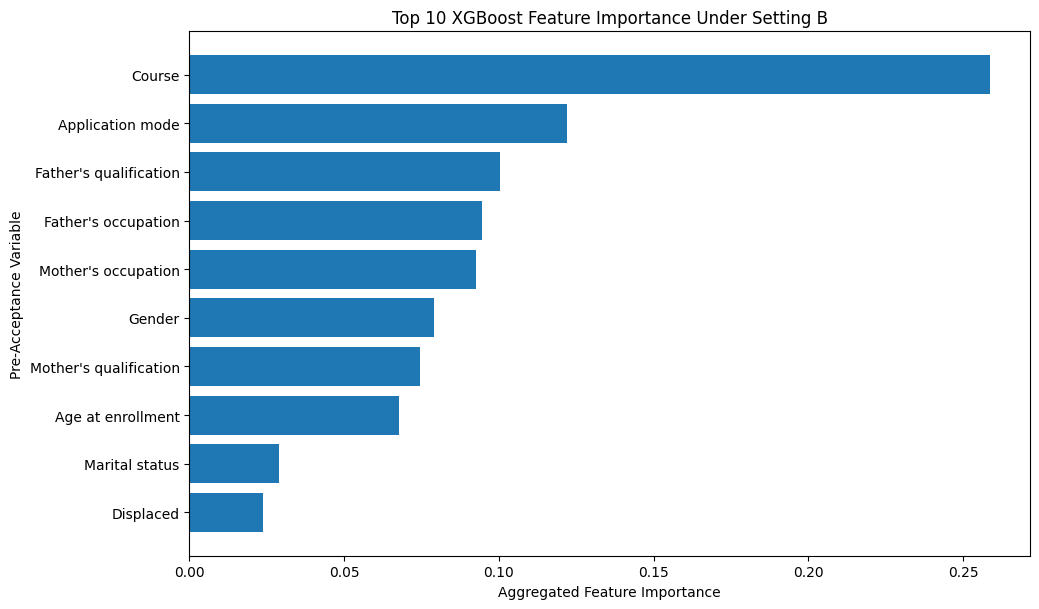

Saved: results\feature_importance_setting_b_xgboost_encoded.csv
Saved: results\feature_importance_setting_b_xgboost_aggregated.csv
Saved: figures\fig2_xgboost_setting_b_feature_importance.png


In [28]:
def clean_encoded_feature_name(name):
    return str(name).replace('cat__', '').replace('num__', '')


def aggregate_to_original_feature(encoded_name, original_features):
    name = clean_encoded_feature_name(encoded_name)
    # Sort by length to avoid partial matching problems.
    for feature in sorted(original_features, key=len, reverse=True):
        if name == feature or name.startswith(feature + '_'):
            return feature
    return name


# Find Setting B + XGBoost result.
setting_b_xgb_result = None
for res in experiment_results:
    if res['setting_name'].startswith('Setting B') and res['model_name'] == 'XGBoost':
        setting_b_xgb_result = res
        break

if setting_b_xgb_result is None:
    raise RuntimeError('Setting B + XGBoost result was not found.')

model = setting_b_xgb_result['model']
encoded_feature_names = setting_b_xgb_result['encoded_feature_names']
importances = model.feature_importances_

feature_importance_encoded = pd.DataFrame({
    'Encoded Feature': [clean_encoded_feature_name(x) for x in encoded_feature_names],
    'Original Feature': [aggregate_to_original_feature(x, setting_b_features) for x in encoded_feature_names],
    'Importance': importances
}).sort_values('Importance', ascending=False)

feature_importance_aggregated = (
    feature_importance_encoded
    .groupby('Original Feature', as_index=False)['Importance']
    .sum()
    .sort_values('Importance', ascending=False)
)

feature_importance_encoded.to_csv(RESULTS_DIR / 'feature_importance_setting_b_xgboost_encoded.csv', index=False)
feature_importance_aggregated.to_csv(RESULTS_DIR / 'feature_importance_setting_b_xgboost_aggregated.csv', index=False)

print('Top 10 aggregated feature importance | Setting B | XGBoost')
display(feature_importance_aggregated.head(10))

# Paper-ready figure: top 10 original features.
top10 = feature_importance_aggregated.head(10).sort_values('Importance', ascending=True)

plt.figure(figsize=(10.5, 6.2))
plt.barh(top10['Original Feature'], top10['Importance'])
plt.xlabel('Aggregated Feature Importance')
plt.ylabel('Pre-Acceptance Variable')
plt.title("Top 10 XGBoost Feature Importance Under Setting B")
plt.tight_layout()

fig2_path = FIGURES_DIR / "fig2_xgboost_setting_b_feature_importance.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", RESULTS_DIR / "feature_importance_setting_b_xgboost_encoded.csv")
print("Saved:", RESULTS_DIR / "feature_importance_setting_b_xgboost_aggregated.csv")
print("Saved:", fig2_path)

## 11. Generate Fig. 3 — Prediction Probability Distribution Under Setting B

This figure shows how the best-performing model separates Graduate and Dropout cases based on predicted dropout probability.

,Actual Class,Predicted Dropout Probability
0,0,0.162921
1,0,0.417510
2,1,0.551257
3,0,0.214980
4,0,0.461584


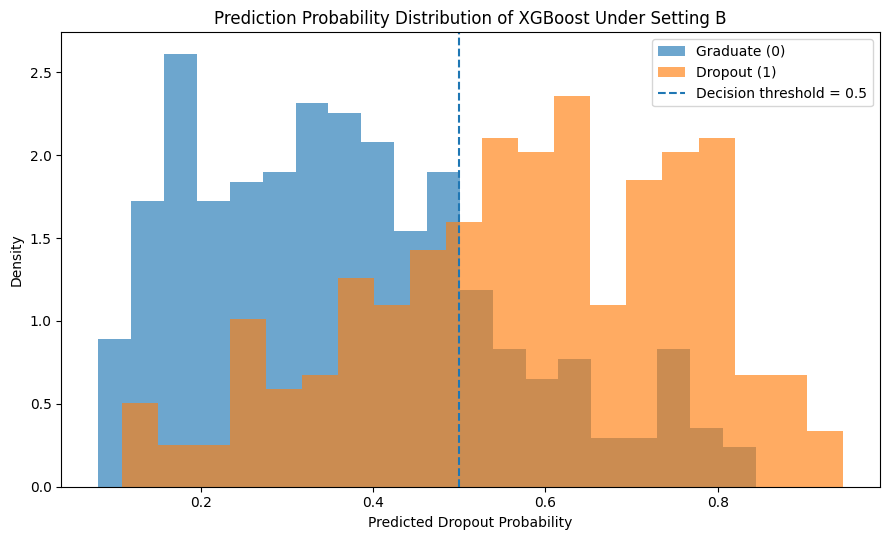

Saved: results\xgboost_setting_b_prediction_probability.csv
Saved: figures\fig3_xgboost_setting_b_probability_distribution.png


In [29]:
# Find Setting B + XGBoost result
setting_b_xgb_result = None

for res in experiment_results:
    if res["setting_name"].startswith("Setting B") and res["model_name"] == "XGBoost":
        setting_b_xgb_result = res
        break

if setting_b_xgb_result is None:
    raise RuntimeError("Setting B + XGBoost result was not found.")

model = setting_b_xgb_result["model"]
X_test_processed = setting_b_xgb_result["X_test_processed"]
y_test = setting_b_xgb_result["y_test"].reset_index(drop=True)

# Predict dropout probability
dropout_probability = model.predict_proba(X_test_processed)[:, 1]

probability_df = pd.DataFrame({
    "Actual Class": y_test,
    "Predicted Dropout Probability": dropout_probability
})

probability_path = RESULTS_DIR / "xgboost_setting_b_prediction_probability.csv"
probability_df.to_csv(probability_path, index=False)

display(probability_df.head())

# Plot probability distribution
graduate_probs = probability_df.loc[
    probability_df["Actual Class"] == 0,
    "Predicted Dropout Probability"
]

dropout_probs = probability_df.loc[
    probability_df["Actual Class"] == 1,
    "Predicted Dropout Probability"
]

plt.figure(figsize=(9, 5.5))
plt.hist(graduate_probs, bins=20, alpha=0.65, label="Graduate (0)", density=True)
plt.hist(dropout_probs, bins=20, alpha=0.65, label="Dropout (1)", density=True)
plt.axvline(0.5, linestyle="--", linewidth=1.5, label="Decision threshold = 0.5")

plt.xlabel("Predicted Dropout Probability")
plt.ylabel("Density")
plt.title("Prediction Probability Distribution of XGBoost Under Setting B")
plt.legend()
plt.tight_layout()

fig3_path = FIGURES_DIR / "fig3_xgboost_setting_b_probability_distribution.png"
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", probability_path)
print("Saved:", fig3_path)

## 12. Final Output Checklist

In [30]:
print('PROCESSED DATA FILES')
for path in sorted(PROCESSED_DATA_DIR.glob('*')):
    print('-', path)

print('\nRESULTS FILES')
for path in sorted(RESULTS_DIR.glob('*')):
    print('-', path)

print('\nFIGURE FILES')
for path in sorted(FIGURES_DIR.glob('*')):
    print('-', path)

print('\nMAIN TABLES')
print('Dataset summary:')
display(dataset_summary)
print('Target distribution:')
display(target_distribution)
print('Model metrics:')
display(results_display)


PROCESSED DATA FILES
- Data\Processed\binary_dataset_graduate_dropout.csv
- Data\Processed\setting_a_processed.joblib
- Data\Processed\setting_a_raw_features_binary.csv
- Data\Processed\setting_b_processed.joblib
- Data\Processed\setting_b_raw_features_binary.csv

RESULTS FILES
- results\classification_report_setting_a_gnb.txt
- results\classification_report_setting_a_xgboost.txt
- results\classification_report_setting_b_gnb.txt
- results\classification_report_setting_b_xgboost.txt
- results\confusion_matrix_table.csv
- results\dataset_transformation_summary.csv
- results\feature_importance_setting_b_xgboost_aggregated.csv
- results\feature_importance_setting_b_xgboost_encoded.csv
- results\feature_setting_definition.csv
- results\model_performance_results_full_precision.csv
- results\model_performance_results_rounded.csv
- results\target_distribution_binary.csv
- results\xgboost_setting_b_prediction_probability.csv

FIGURE FILES
- figures\fig2_feature_boundary.png
- figures\fig2_xgboo

,Description,Count
0,Initial dataset,4424
1,Removed Enrolled records,794
2,Final binary dataset,3630
3,Graduate records,2209
4,Dropout records,1421


Target distribution:


,Class,Count,Percentage
0,Graduate,2209,60.85
1,Dropout,1421,39.15


Model metrics:


,Feature Setting,Model,Accuracy,Precision,Recall,F1-score
0,Setting A: Background-only,Gaussian Naive Bayes,0.3953,0.3901,0.9683,0.5561
1,Setting A: Background-only,XGBoost,0.7052,0.6232,0.6232,0.6232
2,Setting B: Background + Application-related,Gaussian Naive Bayes,0.3994,0.3895,0.9437,0.5514
3,Setting B: Background + Application-related,XGBoost,0.7452,0.6737,0.6761,0.6749
